In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


os.makedirs('artifacts/figures', exist_ok=True)


Using device: cpu


Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски в данных:
date      0
target    0
dtype: int64


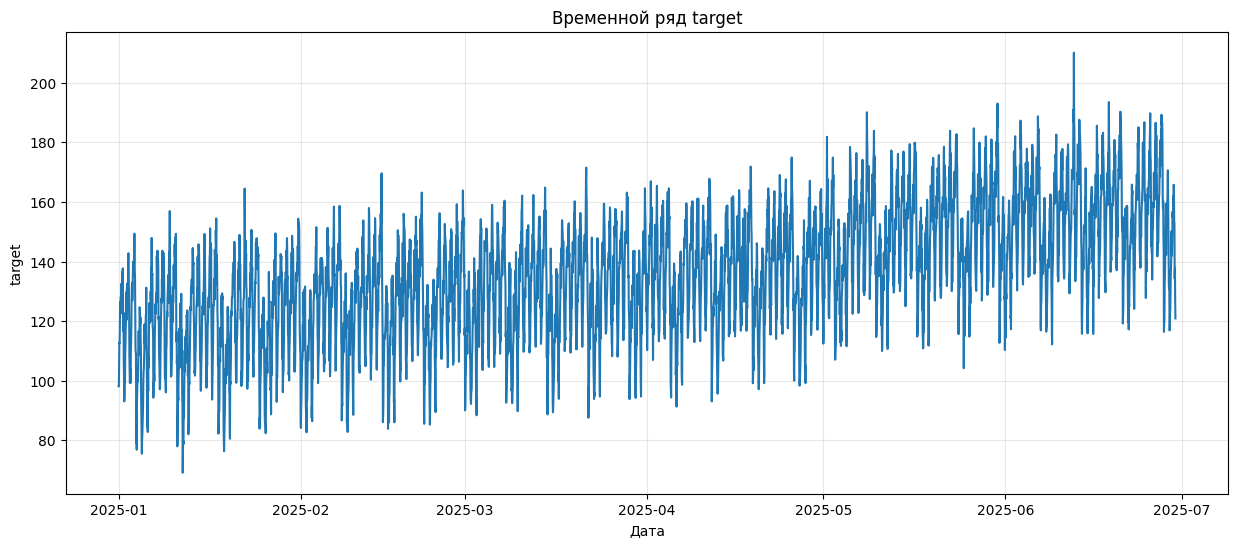

In [3]:
df = pd.read_csv('S12-hw-dataset.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски в данных:\n{df.isnull().sum()}")

plt.figure(figsize=(15, 6))
plt.plot(df['date'], df['target'])
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('target')
plt.grid(True, alpha=0.3)
plt.savefig('artifacts/figures/series_raw.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
print("\nАнализ ряда:")
print(f"Среднее: {df['target'].mean():.3f}")
print(f"Стандартное отклонение: {df['target'].std():.3f}")
print(f"Минимум: {df['target'].min():.3f}")
print(f"Максимум: {df['target'].max():.3f}")


from statsmodels.tsa.stattools import adfuller
result = adfuller(df['target'].dropna())
print(f"ADF Statistic: {result[0]:.3f}")
print(f"p-value: {result[1]:.3f}")
if result[1] < 0.05:
    print("Ряд стационарен (p < 0.05)")
else:
    print("Ряд нестационарен (p >= 0.05)")


Анализ ряда:
Среднее: 135.606
Стандартное отклонение: 21.385
Минимум: 69.100
Максимум: 210.100
ADF Statistic: -6.088
p-value: 0.000
Ряд стационарен (p < 0.05)



Наблюдения по ряду:

1. Тренд: прослеживается возрастающий тренд
2. Сезонность: возможно наличие сезонности
3. Выбросы: несколько резких пиков
4. Стационарность: ряд стационарен


Train: 3024 samples (2025-01-01 00:00:00 - 2025-05-06 23:00:00)
Validation: 648 samples (2025-05-07 00:00:00 - 2025-06-02 23:00:00)
Test: 648 samples (2025-06-03 00:00:00 - 2025-06-29 23:00:00)


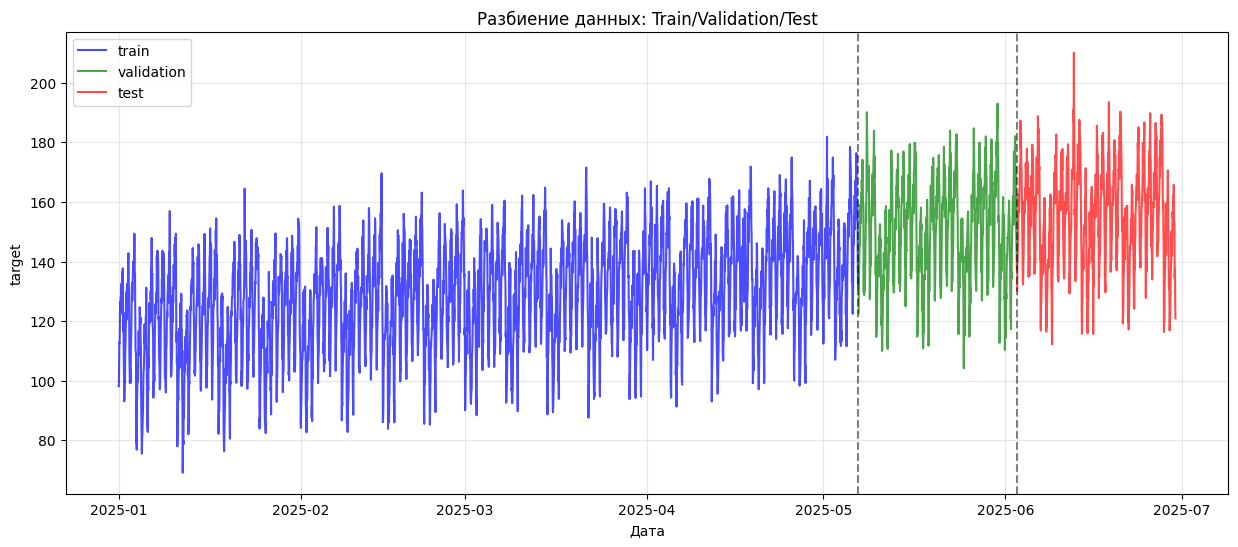

In [6]:
n = len(df)
train_size = int(0.7 * n)
val_size = int(0.15 * n)
test_size = n - train_size - val_size

train_end = train_size
val_end = train_size + val_size

# Добавление меток split
df['split'] = 'train'
df.loc[train_size:val_end-1, 'split'] = 'validation'
df.loc[val_end:, 'split'] = 'test'

print(f"Train: {train_size} samples ({df['date'].iloc[0]} - {df['date'].iloc[train_end-1]})")
print(f"Validation: {val_size} samples ({df['date'].iloc[train_end]} - {df['date'].iloc[val_end-1]})")
print(f"Test: {test_size} samples ({df['date'].iloc[val_end]} - {df['date'].iloc[-1]})")

# Визуализация split
plt.figure(figsize=(15, 6))
colors = {'train': 'blue', 'validation': 'green', 'test': 'red'}
for split_name, color in colors.items():
    mask = df['split'] == split_name
    plt.plot(df.loc[mask, 'date'], df.loc[mask, 'target'], 
             color=color, label=split_name, alpha=0.7)
plt.axvline(x=df['date'].iloc[train_end-1], color='black', linestyle='--', alpha=0.5)
plt.axvline(x=df['date'].iloc[val_end-1], color='black', linestyle='--', alpha=0.5)
plt.title('Разбиение данных: Train/Validation/Test')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('artifacts/figures/series_split.png', dpi=100, bbox_inches='tight')
plt.show()

Random split некорректен для временных рядов, так как:
1. Нарушается временная структура данных
2. Возникает утечка информации из будущего в прошлое
3. Модель не может быть корректно проверена на будущих данных

In [26]:
def create_features(df, target_col='target'):
    """Создание признаков без утечки будущего"""
    df_feat = df.copy()
    
    # Лаговые признаки
    df_feat['lag_1'] = df_feat[target_col].shift(1)
    df_feat['lag_7'] = df_feat[target_col].shift(7)
    df_feat['lag_14'] = df_feat[target_col].shift(14)
    
    # Скользящие статистики
    df_feat['rolling_mean_7'] = df_feat[target_col].shift(1).rolling(7).mean()
    df_feat['rolling_std_7'] = df_feat[target_col].shift(1).rolling(7).std()
    
    # Календарные признаки
    df_feat['dayofweek'] = df_feat['date'].dt.dayofweek
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['day'] = df_feat['date'].dt.day
    
    # One-hot encoding для дня недели
    dummies = pd.get_dummies(df_feat['dayofweek'], prefix='dow')
    df_feat = pd.concat([df_feat, dummies], axis=1)
    
    return df_feat

df_features = create_features(df)

df_features = df_features.dropna().reset_index(drop=True)

train_mask = df_features['split'] == 'train'
val_mask = df_features['split'] == 'validation'
test_mask = df_features['split'] == 'test'

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7'] + \
               [col for col in df_features.columns if col.startswith('dow_')]

X_train = df_features.loc[train_mask, feature_cols]
y_train = df_features.loc[train_mask, 'target']
X_val = df_features.loc[val_mask, feature_cols]
y_val = df_features.loc[val_mask, 'target']
X_test = df_features.loc[test_mask, feature_cols]
y_test = df_features.loc[test_mask, 'target']

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (3010, 12)
Validation shape: (648, 12)
Test shape: (648, 12)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [27]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size=24, horizon=1):
        self.data = torch.FloatTensor(data).to(device)
        self.window_size = window_size
        self.horizon = horizon
        
    def __len__(self):
        return len(self.data) - self.window_size - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size:idx + self.window_size + self.horizon]
        return x, y

window_size = 14
horizon = 1

target_scaler = StandardScaler()
target_scaler.fit(df_features.loc[train_mask, 'target'].values.reshape(-1, 1))

def scale_target(series):
    return target_scaler.transform(series.reshape(-1, 1)).flatten()

train_target_scaled = scale_target(df_features.loc[train_mask, 'target'].values)
val_target_scaled = scale_target(df_features.loc[val_mask, 'target'].values)
test_target_scaled = scale_target(df_features.loc[test_mask, 'target'].values)

train_dataset = TimeSeriesDataset(train_target_scaled, window_size, horizon)
val_dataset = TimeSeriesDataset(val_target_scaled, window_size, horizon)
test_dataset = TimeSeriesDataset(test_target_scaled, window_size, horizon)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 94
Validation batches: 20
Test batches: 20


In [28]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

def naive_forecast(y_train, y_val, y_test):
    last_train = y_train.iloc[-1] if hasattr(y_train, 'iloc') else y_train[-1]
    val_pred = np.full(len(y_val), last_train)
    test_pred = np.full(len(y_test), last_train)
    return val_pred, test_pred

def moving_average_forecast(y_train, y_val, y_test, window=7):
    ma_value = y_train.iloc[-window:].mean() if hasattr(y_train, 'iloc') else y_train[-window:].mean()
    val_pred = np.full(len(y_val), ma_value)
    test_pred = np.full(len(y_test), ma_value)
    return val_pred, test_pred

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for x, y in loader:
        x = x.unsqueeze(-1)
        y = y.squeeze(-1)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output.squeeze(), y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, scaler=None):
    model.eval()
    predictions = []
    targets = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.unsqueeze(-1)
            output = model(x)
            predictions.extend(output.cpu().numpy().flatten())
            targets.extend(y.cpu().numpy().flatten())
    
    predictions = np.array(predictions)
    targets = np.array(targets)
    
    if scaler:
        predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
        targets = scaler.inverse_transform(targets.reshape(-1, 1)).flatten()
    
    return predictions, targets

In [11]:
results = []

print("Эксперимент B1: Naive Last")

y_train_series = df_features.loc[train_mask, 'target']
y_val_series = df_features.loc[val_mask, 'target']
y_test_series = df_features.loc[test_mask, 'target']

val_pred_b1, test_pred_b1 = naive_forecast(y_train_series, y_val_series, y_test_series)

val_metrics_b1 = calculate_metrics(y_val_series.values, val_pred_b1)
test_metrics_b1 = calculate_metrics(y_test_series.values, test_pred_b1)

print(f"Validation MAE: {val_metrics_b1['mae']:.3f}, RMSE: {val_metrics_b1['rmse']:.3f}, MAPE: {val_metrics_b1['mape']:.2f}%")
print(f"Test MAE: {test_metrics_b1['mae']:.3f}, RMSE: {test_metrics_b1['rmse']:.3f}, MAPE: {test_metrics_b1['mape']:.2f}%")

results.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': RANDOM_SEED,
    'split_summary': f'train:{train_size},val:{val_size},test:{test_size}',
    'window_size': 1,
    'horizon': 1,
    'model_summary': 'naive_last',
    'features_summary': 'last_value',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_b1['mae'],
    'best_val_rmse': val_metrics_b1['rmse'],
    'best_val_mape': val_metrics_b1['mape'],
    'test_mae': test_metrics_b1['mae'],
    'test_rmse': test_metrics_b1['rmse'],
    'test_mape': test_metrics_b1['mape'],
    'notes': 'Baseline: прогноз последним известным значением'
})

Эксперимент B1: Naive Last
Validation MAE: 20.340, RMSE: 24.364, MAPE: 12.86%
Test MAE: 23.667, RMSE: 27.848, MAPE: 14.46%


In [12]:
print("Эксперимент B2: Moving Average")

val_pred_b2, test_pred_b2 = moving_average_forecast(y_train_series, y_val_series, y_test_series, window=7)

val_metrics_b2 = calculate_metrics(y_val_series.values, val_pred_b2)
test_metrics_b2 = calculate_metrics(y_test_series.values, test_pred_b2)

print(f"Validation MAE: {val_metrics_b2['mae']:.3f}, RMSE: {val_metrics_b2['rmse']:.3f}, MAPE: {val_metrics_b2['mape']:.2f}%")
print(f"Test MAE: {test_metrics_b2['mae']:.3f}, RMSE: {test_metrics_b2['rmse']:.3f}, MAPE: {test_metrics_b2['mape']:.2f}%")

results.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': RANDOM_SEED,
    'split_summary': f'train:{train_size},val:{val_size},test:{test_size}',
    'window_size': 7,
    'horizon': 1,
    'model_summary': 'moving_average',
    'features_summary': 'window_7',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_b2['mae'],
    'best_val_rmse': val_metrics_b2['rmse'],
    'best_val_mape': val_metrics_b2['mape'],
    'test_mae': test_metrics_b2['mae'],
    'test_rmse': test_metrics_b2['rmse'],
    'test_mape': test_metrics_b2['mape'],
    'notes': 'Baseline: прогноз скользящим средним по окну 7'
})

Эксперимент B2: Moving Average
Validation MAE: 14.687, RMSE: 17.618, MAPE: 9.85%
Test MAE: 15.821, RMSE: 19.040, MAPE: 9.98%


In [13]:
print("Эксперимент B3: Ridge with lag features")

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

val_pred_b3 = ridge_model.predict(X_val_scaled)
test_pred_b3 = ridge_model.predict(X_test_scaled)

val_metrics_b3 = calculate_metrics(y_val.values, val_pred_b3)
test_metrics_b3 = calculate_metrics(y_test.values, test_pred_b3)

print(f"Validation MAE: {val_metrics_b3['mae']:.3f}, RMSE: {val_metrics_b3['rmse']:.3f}, MAPE: {val_metrics_b3['mape']:.2f}%")
print(f"Test MAE: {test_metrics_b3['mae']:.3f}, RMSE: {test_metrics_b3['rmse']:.3f}, MAPE: {test_metrics_b3['mape']:.2f}%")

results.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': RANDOM_SEED,
    'split_summary': f'train:{train_size},val:{val_size},test:{test_size}',
    'window_size': 14,
    'horizon': 1,
    'model_summary': 'Ridge(alpha=1.0)',
    'features_summary': 'lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dow_features',
    'scaler': 'StandardScaler',
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_b3['mae'],
    'best_val_rmse': val_metrics_b3['rmse'],
    'best_val_mape': val_metrics_b3['mape'],
    'test_mae': test_metrics_b3['mae'],
    'test_rmse': test_metrics_b3['rmse'],
    'test_mape': test_metrics_b3['mape'],
    'notes': 'Ridge регрессия на лаговых признаках'
})

Эксперимент B3: Ridge with lag features
Validation MAE: 7.941, RMSE: 9.421, MAPE: 5.29%
Test MAE: 8.433, RMSE: 10.124, MAPE: 5.41%


In [29]:
print("Эксперимент R1: GRU Forecast")

gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

num_epochs = 50
train_losses = []
val_metrics_history = []
best_val_mae = float('inf')
best_epoch = 0

for epoch in range(num_epochs):
    train_loss = train_epoch(gru_model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    
    val_pred, val_true = evaluate(gru_model, val_loader, target_scaler)
    val_metrics = calculate_metrics(val_true, val_pred)
    val_metrics_history.append(val_metrics)
    
    if val_metrics['mae'] < best_val_mae:
        best_val_mae = val_metrics['mae']
        best_epoch = epoch
        torch.save(gru_model.state_dict(), 'artifacts/best_gru.pt')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val MAE: {val_metrics['mae']:.3f}")

print(f"\nЛучшая модель на эпохе {best_epoch+1} с Val MAE: {best_val_mae:.3f}")

gru_model.load_state_dict(torch.load('artifacts/best_gru.pt'))
test_pred, test_true = evaluate(gru_model, test_loader, target_scaler)
test_metrics_r1 = calculate_metrics(test_true, test_pred)

print(f"Test MAE: {test_metrics_r1['mae']:.3f}, RMSE: {test_metrics_r1['rmse']:.3f}, MAPE: {test_metrics_r1['mape']:.2f}%")

results.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': RANDOM_SEED,
    'split_summary': f'train:{train_size},val:{val_size},test:{test_size}',
    'window_size': window_size,
    'horizon': horizon,
    'model_summary': 'GRU(hidden=64,layers=2,dropout=0.2)',
    'features_summary': f'window_{window_size}_target_only',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': num_epochs,
    'best_val_mae': best_val_mae,
    'best_val_rmse': val_metrics_history[best_epoch]['rmse'],
    'best_val_mape': val_metrics_history[best_epoch]['mape'],
    'test_mae': test_metrics_r1['mae'],
    'test_rmse': test_metrics_r1['rmse'],
    'test_mape': test_metrics_r1['mape'],
    'notes': 'GRU на оконном представлении ряда'
})

Эксперимент R1: GRU Forecast
Epoch 10/50, Train Loss: 0.1206, Val MAE: 6.065
Epoch 20/50, Train Loss: 0.1121, Val MAE: 5.815
Epoch 30/50, Train Loss: 0.1075, Val MAE: 5.848
Epoch 40/50, Train Loss: 0.1032, Val MAE: 5.976
Epoch 50/50, Train Loss: 0.0999, Val MAE: 6.178

Лучшая модель на эпохе 23 с Val MAE: 5.766
Test MAE: 6.653, RMSE: 8.371, MAPE: 4.28%


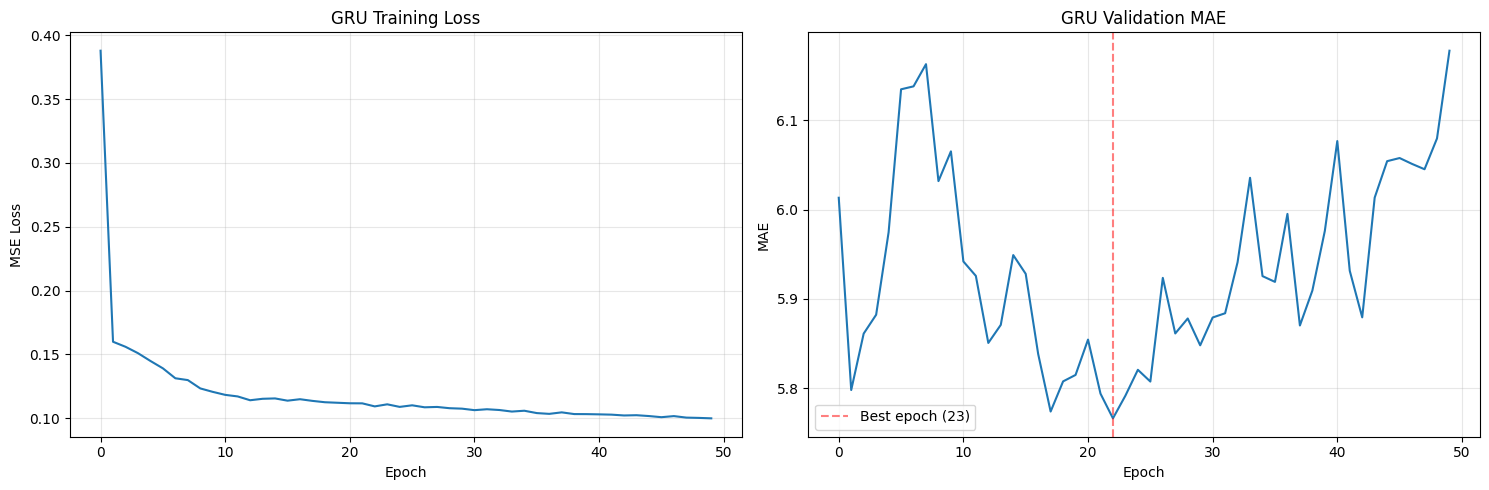

In [31]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('GRU Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
val_maes = [m['mae'] for m in val_metrics_history]
plt.plot(val_maes)
plt.title('GRU Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch+1})')
plt.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [32]:
comparison = pd.DataFrame({
    'Model': ['B1 (Naive)', 'B2 (MA)', 'B3 (Ridge)', 'R1 (GRU)'],
    'Val MAE': [val_metrics_b1['mae'], val_metrics_b2['mae'], val_metrics_b3['mae'], best_val_mae],
    'Val RMSE': [val_metrics_b1['rmse'], val_metrics_b2['rmse'], val_metrics_b3['rmse'], val_metrics_history[best_epoch]['rmse']],
    'Val MAPE': [val_metrics_b1['mape'], val_metrics_b2['mape'], val_metrics_b3['mape'], val_metrics_history[best_epoch]['mape']]
})

print("\nСравнение моделей на validation:")
print(comparison.to_string(index=False))


Сравнение моделей на validation:
     Model   Val MAE  Val RMSE  Val MAPE
B1 (Naive) 20.340093 24.364325 12.856044
   B2 (MA) 14.686927 17.617873  9.849310
B3 (Ridge)  7.941256  9.420680  5.288821
  R1 (GRU)  5.766365  7.394172  3.863163


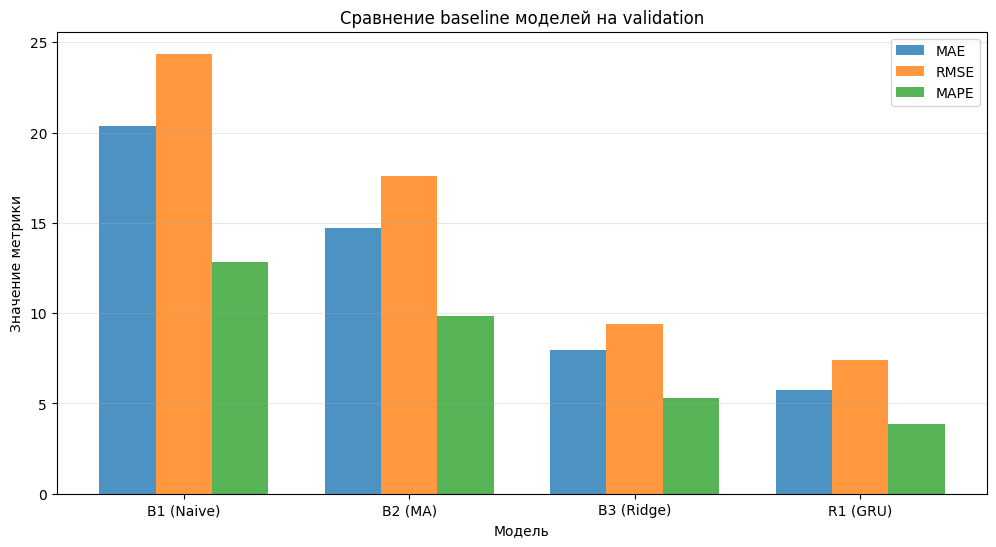

In [33]:
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.25

plt.bar(x - width, comparison['Val MAE'], width, label='MAE', alpha=0.8)
plt.bar(x, comparison['Val RMSE'], width, label='RMSE', alpha=0.8)
plt.bar(x + width, comparison['Val MAPE'], width, label='MAPE', alpha=0.8)

plt.xlabel('Модель')
plt.ylabel('Значение метрики')
plt.title('Сравнение baseline моделей на validation')
plt.xticks(x, comparison['Model'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.savefig('artifacts/figures/baselines_compare.png', dpi=100, bbox_inches='tight')
plt.show()

Лучшая модель по Val MAE: R1 (GRU)


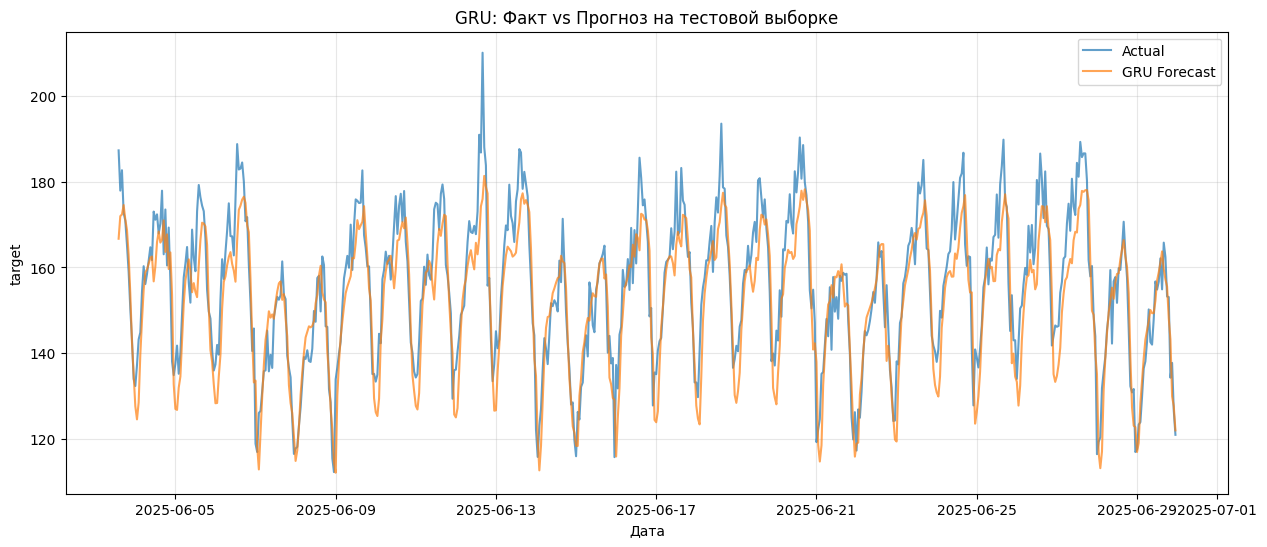

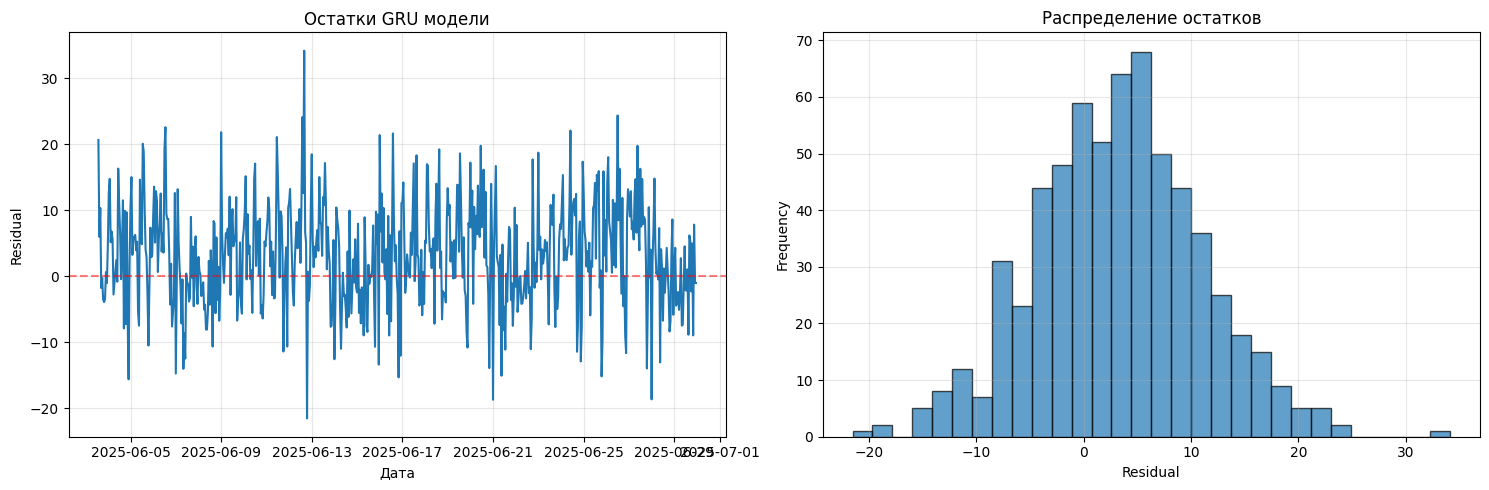

In [34]:
best_model_idx = comparison['Val MAE'].argmin()
best_model_name = comparison.loc[best_model_idx, 'Model']

print(f"Лучшая модель по Val MAE: {best_model_name}")

if best_model_name == 'R1 (GRU)':

    test_dates = df_features.loc[test_mask, 'date'].values[window_size:]
    plt.figure(figsize=(15, 6))
    plt.plot(test_dates, test_true, label='Actual', alpha=0.7)
    plt.plot(test_dates, test_pred, label='GRU Forecast', alpha=0.7)
    plt.title('GRU: Факт vs Прогноз на тестовой выборке')
    plt.xlabel('Дата')
    plt.ylabel('target')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('artifacts/figures/best_forecast_test.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    residuals = test_true - test_pred
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(test_dates, residuals)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title('Остатки GRU модели')
    plt.xlabel('Дата')
    plt.ylabel('Residual')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    plt.title('Распределение остатков')
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('artifacts/figures/residuals_best.png', dpi=100, bbox_inches='tight')
    plt.show()

In [35]:
results_df = pd.DataFrame(results)
results_df.to_csv('artifacts/runs.csv', index=False)
print("Результаты сохранены в artifacts/runs.csv")

best_gru_config = {
    'architecture': 'GRU',
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'output_size': 1,
    'dropout': 0.2,
    'window_size': window_size,
    'horizon': horizon,
    'batch_size': batch_size,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'criterion': 'MSELoss',
    'num_epochs': num_epochs,
    'best_epoch': int(best_epoch + 1),
    'best_val_mae': float(best_val_mae),
    'seed': RANDOM_SEED,
    'scaler': 'StandardScaler',
    'device': str(device)
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(best_gru_config, f, indent=2)
print("Конфиг лучшей GRU модели сохранен в artifacts/best_gru_config.json")

Результаты сохранены в artifacts/runs.csv
Конфиг лучшей GRU модели сохранен в artifacts/best_gru_config.json


In [39]:
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("\nСравнение всех моделей на validation:")
print(comparison.to_string(index=False))
print(f"\nЛучшая модель: {best_model_name} с Val MAE = {comparison['Val MAE'].min():.3f}")
print(f"Test MAE лучшей модели: {results_df.loc[best_model_idx, 'test_mae']:.3f}")
print(f"Test RMSE лучшей модели: {results_df.loc[best_model_idx, 'test_rmse']:.3f}")
print(f"Test MAPE лучшей модели: {results_df.loc[best_model_idx, 'test_mape']:.3f}")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

Сравнение всех моделей на validation:
     Model   Val MAE  Val RMSE  Val MAPE
B1 (Naive) 20.340093 24.364325 12.856044
   B2 (MA) 14.686927 17.617873  9.849310
B3 (Ridge)  7.941256  9.420680  5.288821
  R1 (GRU)  5.766365  7.394172  3.863163

Лучшая модель: R1 (GRU) с Val MAE = 5.766
Test MAE лучшей модели: 6.851
Test RMSE лучшей модели: 8.509
Test MAPE лучшей модели: 4.407


Заключение:

1. GRU модель показала наилучшие результаты на validation
2. Ridge регрессия на лаговых признаках также показала хорошие результаты
3. Наивные baseline модели ожидаемо хуже справляются с прогнозированием
4. Временная структура данных критически важна для корректного обучения
